Library Imports

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV Parsing

In [19]:
df = pd.read_csv("customers-100000.csv")

In [20]:
df

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,ffeCAb7AbcB0f07,Jared,Jarvis,Sanchez-Fletcher,Hatfieldshire,Eritrea,274.188.8773x41185,001-215-760-4642x969,gabriellehartman@benjamin.com,2021-11-11,https://www.mccarthy.info/
1,2,b687FfC4F1600eC,Marie,Malone,Mckay PLC,Robertsonburgh,Botswana,283-236-9529,(189)129-8356x63741,kstafford@sexton.com,2021-05-14,http://www.reynolds.com/
2,3,9FF9ACbc69dcF9c,Elijah,Barrera,Marks and Sons,Kimbury,Barbados,8252703789,459-916-7241x0909,jeanettecross@brown.com,2021-03-17,https://neal.com/
3,4,b49edDB1295FF6E,Sheryl,Montgomery,"Kirby, Vaughn and Sanders",Briannaview,Antarctica (the territory South of 60 deg S),425.475.3586,(392)819-9063,thomassierra@barrett.com,2020-09-23,https://www.powell-bryan.com/
4,5,3dcCbFEB17CCf2E,Jeremy,Houston,Lester-Manning,South Brianna,Micronesia,+1-223-666-5313x4530,252-488-3850x692,rubenwatkins@jacobs-wallace.info,2020-09-18,https://www.carrillo.com/
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,67F24BEBAa16d1c,Dana,Winters,"Pham, Conner and Wade",Kirkfurt,Sierra Leone,820-930-7616,+1-061-779-5511x3267,ppittman@watson.com,2020-05-30,https://www.maynard.com/
99996,99997,17b1dbDaB2ad0fB,Gabriela,Pacheco,Fletcher-Hodge,Virginiahaven,Comoros,+1-480-464-8646,(015)822-1443x33211,murillojeremiah@mcmahon-medina.com,2022-04-09,http://www.eaton.com/
99997,99998,c586CFBA6fb9dcC,Mikayla,Hubbard,Austin Ltd,Sheriville,Mayotte,+1-567-149-3941x67118,361-900-3348,orhodes@harding-galloway.biz,2022-03-05,https://hayes.com/
99998,99999,bb6cb6AC9d0CAf7,Javier,Berg,Welch Inc,Stephenschester,Belarus,(381)105-4698,360-905-2308x301,rodneytanner@jennings-boone.net,2021-12-29,http://zuniga.com/


Additional Data

In [147]:
df["Full Name"] = (df["First Name"] + " " + df["Last Name"]).tolist()

In [190]:
subscription_year=[]
for date in df["Subscription Date"].tolist():
    subscription_year.append(int(date[:4]))
df["Subscription Year"] = subscription_year

Dataframe Insight

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Index              100000 non-null  int64 
 1   Customer Id        100000 non-null  object
 2   First Name         100000 non-null  object
 3   Last Name          100000 non-null  object
 4   Company            100000 non-null  object
 5   City               100000 non-null  object
 6   Country            100000 non-null  object
 7   Phone 1            100000 non-null  object
 8   Phone 2            100000 non-null  object
 9   Email              100000 non-null  object
 10  Subscription Date  100000 non-null  object
 11  Website            100000 non-null  object
 12  Full Name          100000 non-null  object
 13  Subscription Year  100000 non-null  int64 
dtypes: int64(2), object(12)
memory usage: 10.7+ MB


In [149]:
df.describe(include=['O'])

,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,690,1000,71994,49154,243,100000,100000,99995,880,50471,92944
top,ffeCAb7AbcB0f07,Joan,Campbell,Wilkerson Ltd,Lake Frederick,Congo,274.188.8773x41185,001-215-760-4642x969,julia03@briggs.com,2020-12-11,https://guzman.com/,Jesse Gordon
freq,1,183,139,17,16,835,1,1,2,155,22,4


In [189]:
n = 10
topn_countries_value = df["Country"].value_counts().head(n).tolist()
topn_countries_name = df["Country"].value_counts().index[:n].tolist()
topn_subscriptionyear_value = df["Subscription Year"].value_counts().tolist()
topn_subscriptionyear_name = df["Subscription Year"].value_counts().index[:n].tolist()


In [ ]:
df_top10_countries = pd.DataFrame(
    {'Country': topn_countries_name,
     'Count': topn_countries_value
    })
df_subscriptionyear = pd.DataFrame(
    {'Year': topn_subscriptionyear_name,
     'Count': topn_subscriptionyear_value
    })

Subscription By Country

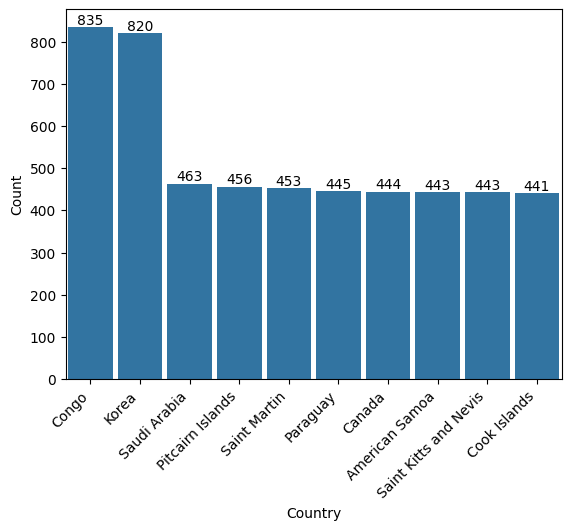

In [187]:
ax = sns.barplot(df_top10_countries, x="Country", y="Count", estimator="sum", errorbar=None, width=0.9)
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], fontsize=10);

Subscription By Year

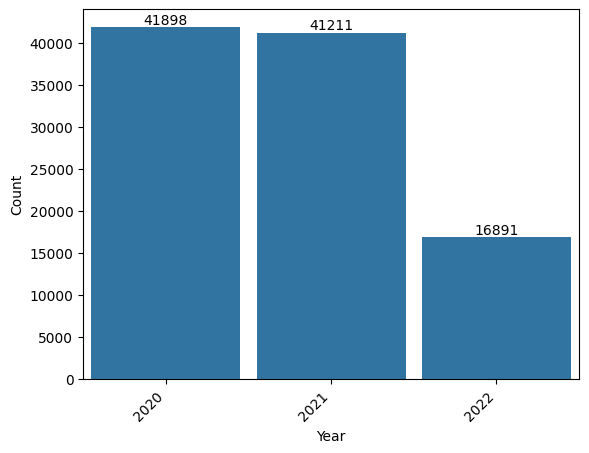

In [188]:
ax = sns.barplot(df_subscriptionyear, x="Year", y="Count", estimator="sum", errorbar=None, width=0.9)
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], fontsize=10);

In [197]:
y1 = ((topn_subscriptionyear_value[0] - topn_subscriptionyear_value[1])/topn_subscriptionyear_value[0])*100
y2 = ((topn_subscriptionyear_value[1] - topn_subscriptionyear_value[2])/topn_subscriptionyear_value[1])*100
print(y1)
print(y2)

1.6396964055563512
59.01337021668972


In [ ]:
df.loc[df["Email"]=="julia03@briggs.com"]

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
90751,90752,8A2E9e5af981CBd,Alvin,Stephens,Bolton-Torres,New Rose,Liechtenstein,2986388860,+1-337-311-2845x19687,julia03@briggs.com,2022-05-16,http://cortez.info/
96681,96682,64ff4a97cCF99Da,Kathy,Rojas,Burke-Schroeder,Reginaldland,Ghana,001-570-596-7205x878,152.042.4114x03141,julia03@briggs.com,2020-04-17,http://www.adkins-carney.com/


In [150]:
df.loc[df["Full Name"]=="Jesse Gordon"]

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
8605,8606,d0F8bD10c2EB140,Jesse,Gordon,Herring and Sons,East Leslie,Burundi,(022)090-7454,(248)002-7266x676,wsanchez@delacruz.com,2020-12-27,http://lucero.com/,Jesse Gordon
39722,39723,E5cAfd1F7904c1d,Jesse,Gordon,Blake and Sons,Oscarfort,Timor-Leste,875.020.4865x89856,793.969.6634,ortegadebra@callahan.com,2022-03-29,http://stanton-morales.org/,Jesse Gordon
57128,57129,0fCf7EBA42eA6ac,Jesse,Gordon,Ponce Group,Lake Tricia,Cocos (Keeling) Islands,(974)583-2414x18142,186.549.3939x1118,randy49@cochran.info,2021-09-19,http://shannon-spencer.com/,Jesse Gordon
71434,71435,2fAB80Bd359AddF,Jesse,Gordon,"Schmidt, Henderson and Castillo",West Jillian,Zimbabwe,405.981.0315x8839,045-078-3898,pibarra@sanchez.org,2021-06-30,https://hoover.com/,Jesse Gordon


In [151]:
df.loc[df["Website"]=="https://guzman.com/"]

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website,Full Name
5922,5923,Aef4494DeDb2ffA,Jillian,Odonnell,Lucero Inc,Sharonmouth,Kenya,(939)552-9732x0775,414-238-9259,dianagriffith@rivers.org,2022-01-25,https://guzman.com/,Jillian Odonnell
6606,6607,0317a8B98CA1B19,Diamond,Duke,Howard-Hall,North Adriennemouth,Wallis and Futuna,8895733515,805-761-4096x68164,tylerserrano@spence.biz,2020-10-17,https://guzman.com/,Diamond Duke
8955,8956,D4dEe98EcdFab76,Michelle,Gillespie,"Shields, Koch and Gonzales",North Meredithside,Belarus,001-694-891-7360x50780,(102)693-0737,ross22@dawson.com,2020-12-03,https://guzman.com/,Michelle Gillespie
13229,13230,2Ce7C577f83fb84,Cathy,Lamb,Conrad-Mcdowell,East Francesville,Angola,937-034-0088,445-656-8037x8037,mckayjudith@singleton-dunn.com,2020-01-24,https://guzman.com/,Cathy Lamb
19796,19797,CAFCdAdC9BafFe6,Ross,Newton,Moon-Allison,Goldenfurt,Montserrat,939-080-2896,+1-440-029-0247x7186,mistycarr@patton.info,2020-02-09,https://guzman.com/,Ross Newton
20033,20034,1adbcb5a77cbAc5,Lacey,Mcmahon,Bowman Inc,New Terrance,British Virgin Islands,931-951-7294x346,280.904.1800,gbarrett@rhodes.com,2020-08-01,https://guzman.com/,Lacey Mcmahon
24410,24411,CB7Ef1B0504bCa5,Kara,Davies,Foley and Sons,West Frederick,Niger,(525)843-2245,4680593893,mindycarey@watkins-larson.info,2021-11-26,https://guzman.com/,Kara Davies
25150,25151,e7B6E2b7e4fBdBc,Terrance,Waller,Cantrell PLC,East Dominique,Kyrgyz Republic,001-508-324-2920x8169,600-102-0213x2337,darrenvargas@lozano.info,2020-02-12,https://guzman.com/,Terrance Waller
37341,37342,C25E1B3FD7FDAdf,Dorothy,Zavala,Schroeder-Kennedy,Mclaughlinfort,Morocco,5046676713,658-608-5574x816,christina10@berg.com,2021-12-07,https://guzman.com/,Dorothy Zavala
37782,37783,f88EECDEE7CaEe0,Tony,Walker,"Trevino, Singh and Chaney",Lake Darylshire,Slovenia,001-575-936-2383x5319,+1-649-020-8066x4914,combsgarrett@gamble.com,2020-03-04,https://guzman.com/,Tony Walker


Gathered Insight

This csv consist of customer data who subscribes a platform. It consist of 100K rows and the data itself is clear with no null value. However, the data shows a sign of low data integrity. There are 2 customers having the same email address (julia03@briggs.com), worth checking to prevent duplication and data missmatch. Website column's data integrity is also questionable because the majority of it is different with the company name, take https://guzman.com/ for example where there is no company with "guzman" keyword found. Most subscribers come from Congo and Kongo with over 800 users. The subscribers hits peak at 2020 and only shrinking by 1.6% at 2021. At 2022 however, is shrinking steeply by 59%, worth confirming if the data date just in case it is a rolling year.